In [1]:
'''
The goal of this notebook is to recreate the data processing pipeline and model training loop, that I previously wrote in Monai, using 
PyTorch, TorchVision, and NiBabel... This should allow me to leverage my RTX 5070 GPU
MAJOR STEPS:
-Load Images
-Use matplotlib to do some cursory image evaluation (determine voxel intensity and ideal constrast, image dimensions and voxel spacing, etc. 
-Compose transformations that were used in previous notebook
-Apply transformations to data
-Train UNet model
'''
!pip install tqdm
from tqdm import tqdm
import os
import random
from glob import glob
from pathlib import Path
from helpers import show_sample, build_img_set, plot_intensity_histograms
from transforms import loadimagesd, permutechannels, toTensor, stackTensors, cropToForeground, normalizeIntensities, voxelSpacing, remapLabel, DivisiblePad, random_flip, padToShape, centerCropIfLargerThan
import torch
import torchvision
import torchvision.transforms as transforms
from dataset import TrainDataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt #for visualizing images and plotting summary stats
import nibabel as nib #for loading niftis
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from DoubleConvolution import UNET
from utils import (
    load_checkpoint,
    save_checkpoint,
    check_accuracy,
    save_predictions_as_imgs,
    get_loaders,
)
print("torch version: ", torch.__version__)
print("torchvision version: ", torchvision.__version__)
print(torch.version.cuda)
print("hello")

torch version:  2.8.0.dev20250620+cu128
torchvision version:  0.23.0.dev20250620+cu128
12.8
hello


In [2]:
#load file paths and store as a dictionary for each subject
#Path makes filepath to data directory, / appends to that filepath
data_root = Path("data") / "brats20_output" / "Training" #create path object that points to our data directory
print(type(data_root))

train_subjects, val_subjects = build_img_set(data_root)



<class 'pathlib.PosixPath'>
Loaded 369 complete subject dictionaries.
returning a training set of length 295 and validation set of length 74


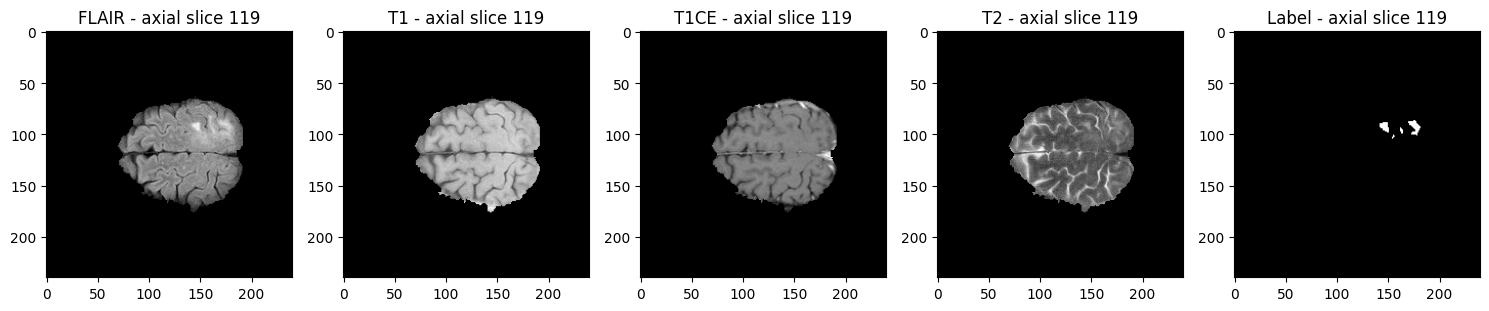

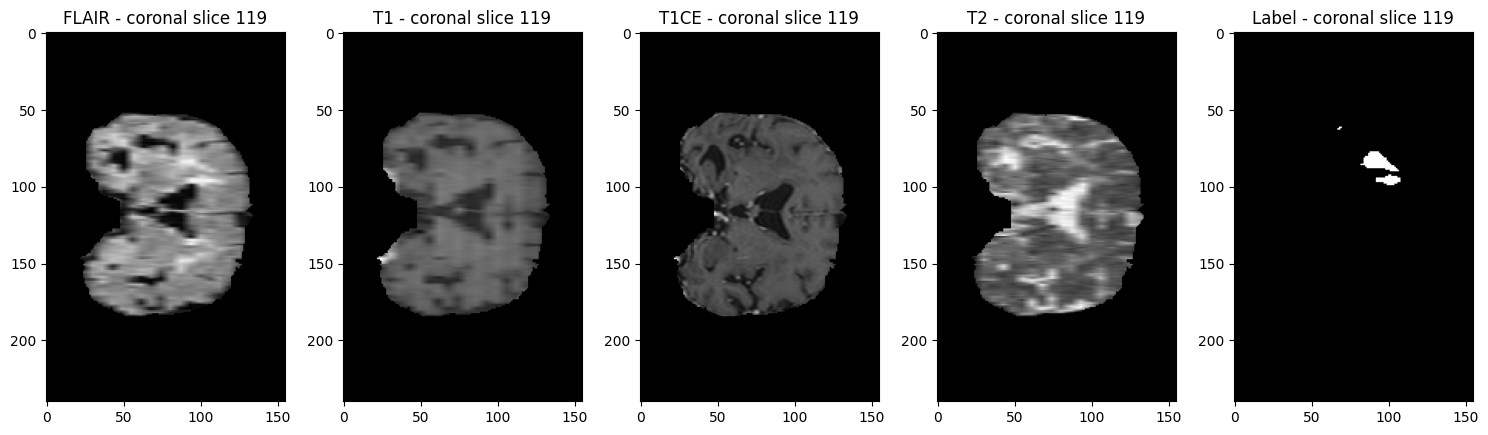

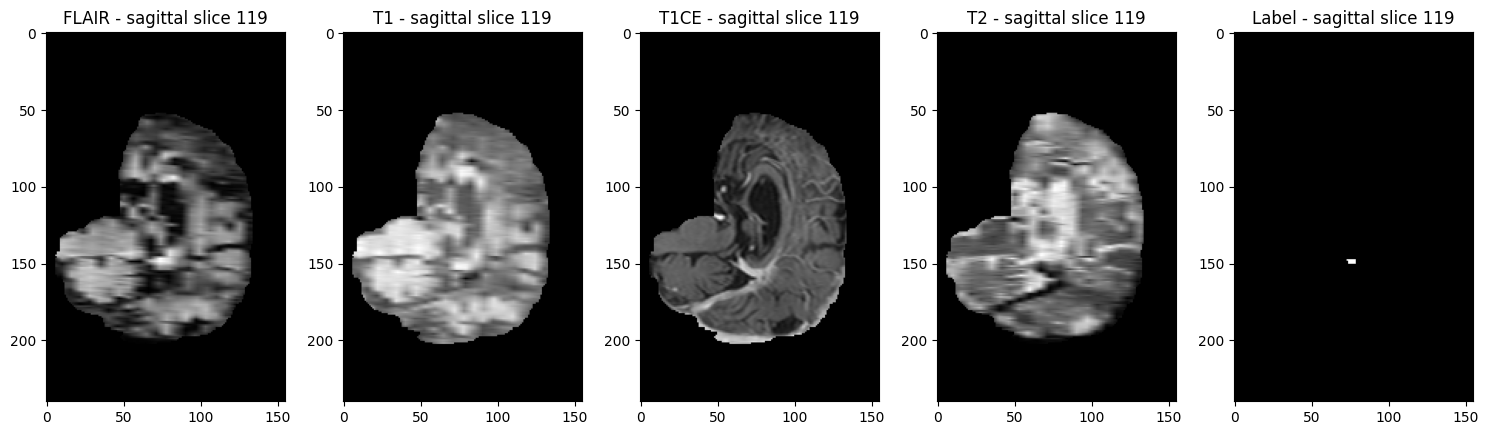

In [3]:
show_sample(train_subjects, 0, "axial", 119)
show_sample(train_subjects, 0, "coronal", 119)
show_sample(train_subjects, 0, "sagittal", 119)


subject  0


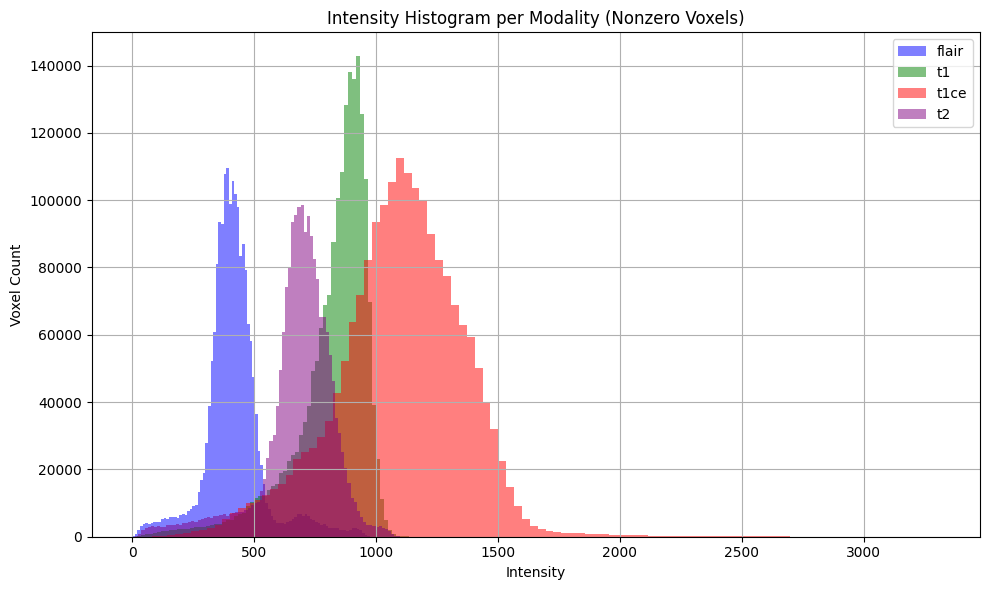

subject  1


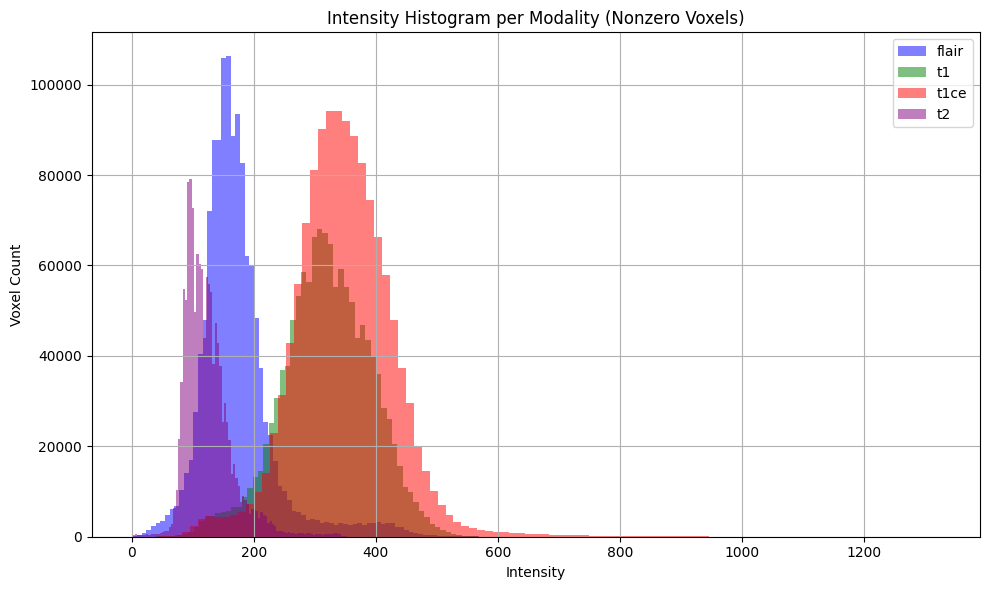

subject  2


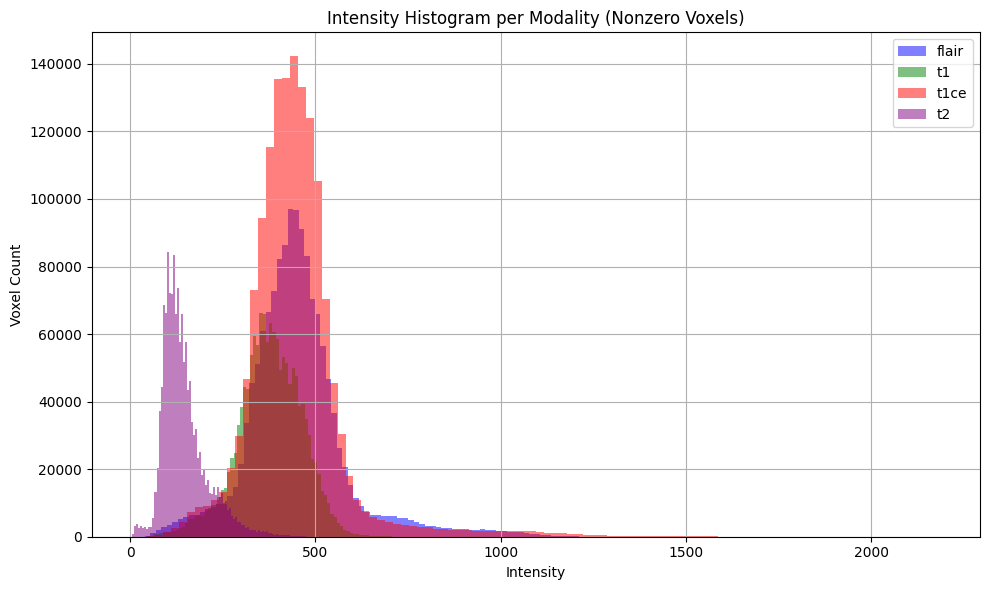

subject  3


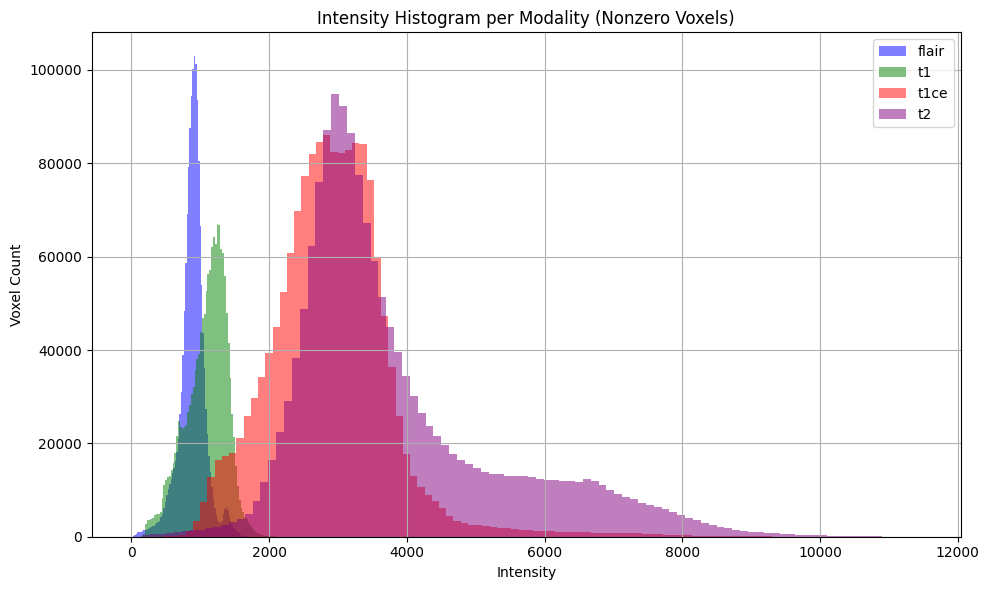

subject  4


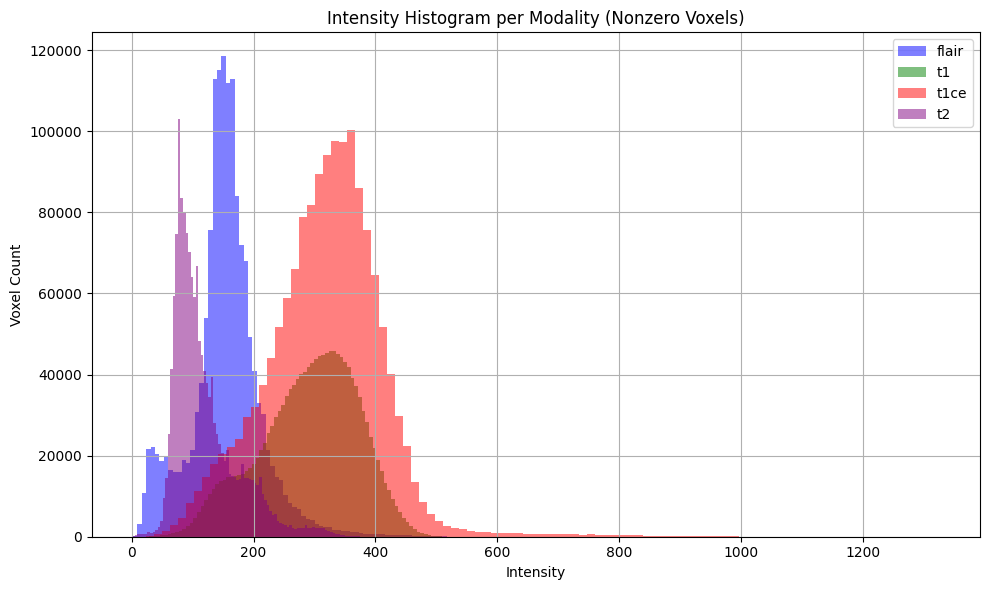

subject  5


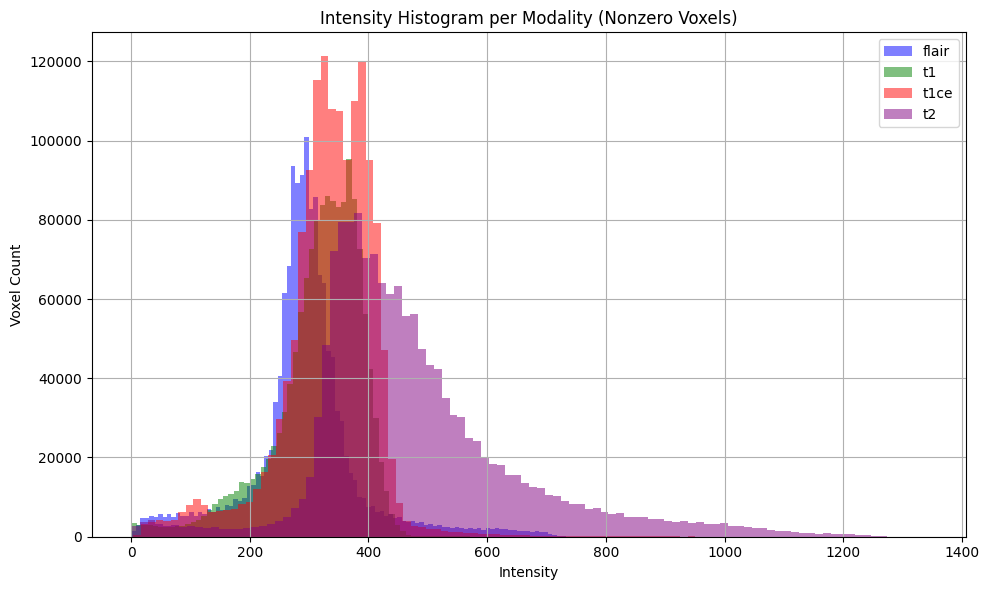

subject  6


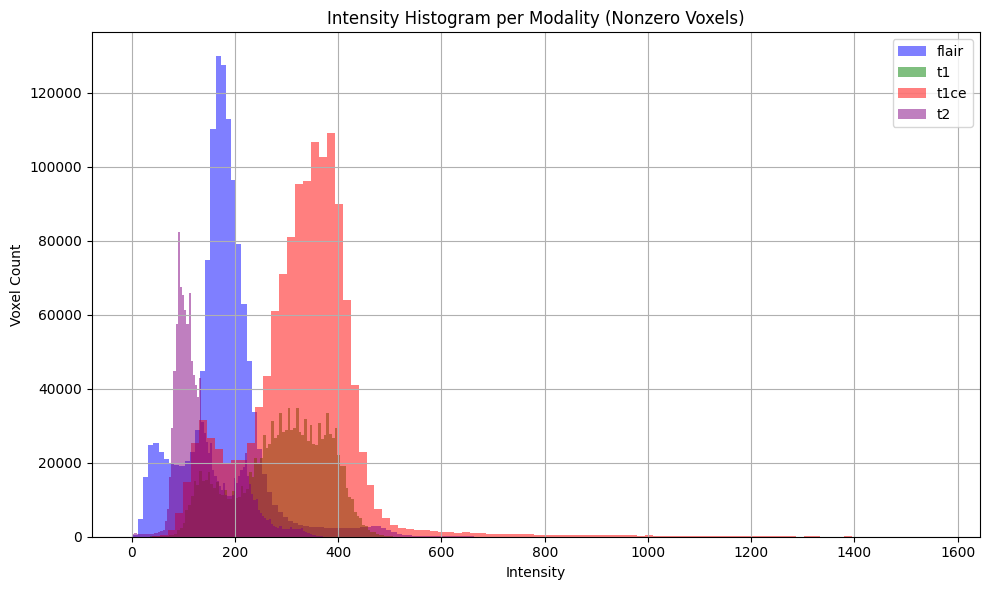

subject  7


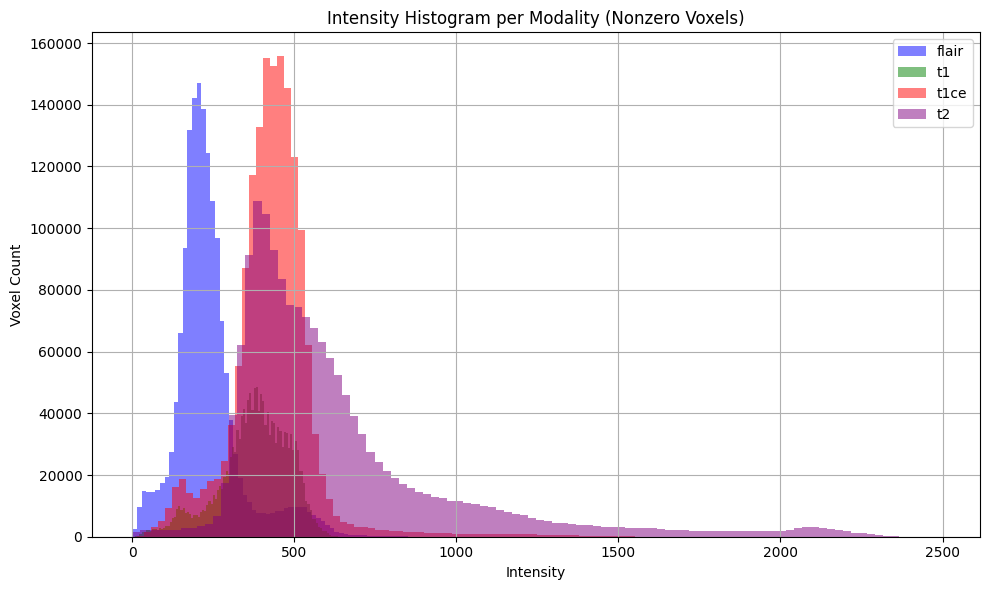

subject  8


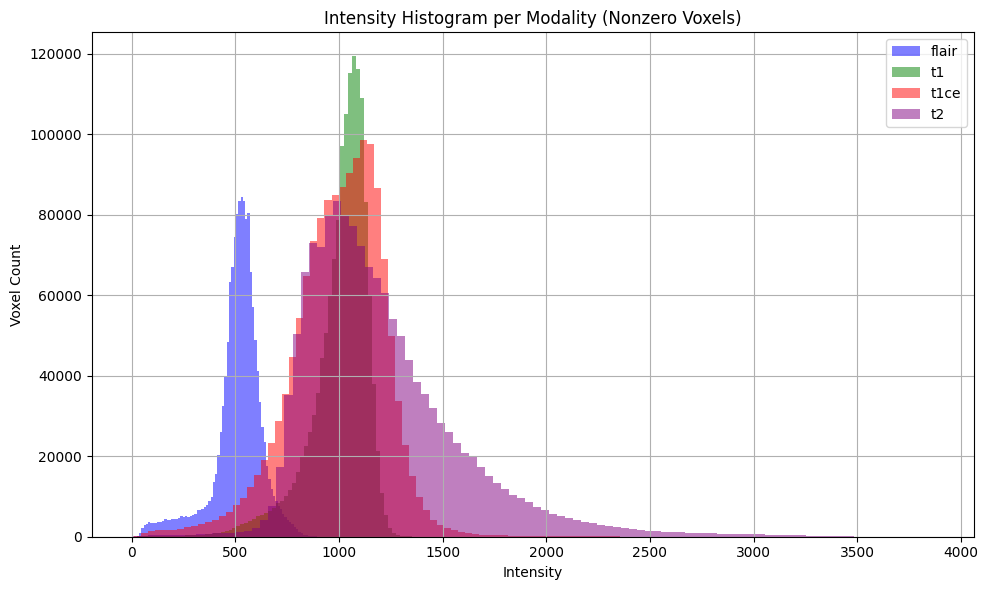

subject  9


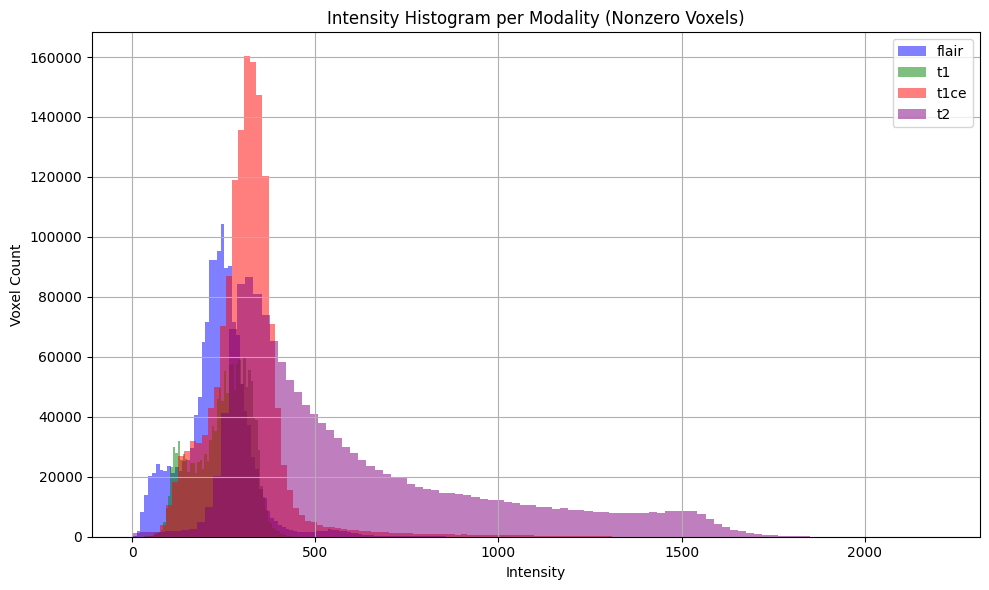

'\nThese plots show that intensity can vary a great deal between patients, thus we should scale the intensity on a per-patient basis\n'

In [4]:
'''
What we have as the value in each voxel is known as the "intensity". Essentially the amount of light being reflected at that point.
Intensity works a little differently for our different image types. 
T1 scans brighten the fat and darken the water
T2 brightens the water and darkens the fat
FLAIR suppresses CSF so lesions stand out
T1CE T1 with contrast agent, brightens tumors
Intensities can span from 0 to 10000 based on the MRI machine, but our screens can only interpret values 0-255 (8-bit) so we need to optimally scale
the intensities to values that can be interpreted by our machine.
'''
for i in range(10):
    print("subject ", i)
    plot_intensity_histograms(val_subjects[i])
'''
These plots show that intensity can vary a great deal between patients, thus we should scale the intensity on a per-patient basis
'''

In [5]:
'''
So we have confirmed that we need to adjust the contrast for our images, now we look at the raw image data to glean more insight
'''
print(nib.load(train_subjects[1]["t1"]).header)
print(nib.load(train_subjects[1]["t1"]).affine)
'''
The rows to pay attention to are dim, pixdim, and datatype
dim refers to the dimensions of our 3D image, it is 240 voxels by 240 voxels by 155 voxels, we will crop our images to remove as much background as possible
we need to make sure in doing so that the dimensions of each image all match

pixdim refers to the dimensions of each voxel, if the images are not distorted then we would expect these values to be 1 by 1 by 1. The images in this dataset
all have non-distorted pixels. Thus we will not need to rescale them during transformation. But normally if we were getting a collection of images from
a number of different hospitals, we would expect some images to be distorted when they are rendered on a screen (especially from older MRI machines).
It is important to review this and normalize the voxel dimensions for each image

Finally, we see the datatype of our label image is 16 bit integer, this is good and expected, but we need to keep an eye on this. Many transformations we 
apply will change this datatype to a float... We will need to make sure we change it back to an int
'''

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 240 240 155   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1. 1. 1. 1. 0. 0. 0. 0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : aligned
sform_code      : scanner
quatern_b       : 0.0
quatern_c       : 0.0
quatern_d       : 1.0
qoffset_x       : -0.0
qoffset_y       : 239.0
qoffset_z       : 0.

'\nThe rows to pay attention to are dim, pixdim, and datatype\ndim refers to the dimensions of our 3D image, it is 240 voxels by 240 voxels by 155 voxels, we will crop our images to remove as much background as possible\nwe need to make sure in doing so that the dimensions of each image all match\n\npixdim refers to the dimensions of each voxel, if the images are not distorted then we would expect these values to be 1 by 1 by 1. The images in this dataset\nall have non-distorted pixels. Thus we will not need to rescale them during transformation. But normally if we were getting a collection of images from\na number of different hospitals, we would expect some images to be distorted when they are rendered on a screen (especially from older MRI machines).\nIt is important to review this and normalize the voxel dimensions for each image\n\nFinally, we see the datatype of our label image is 16 bit integer, this is good and expected, but we need to keep an eye on this. Many transformations 

In [3]:
'''
Lets test loading images...
'''
shuffled_subjects = train_subjects[:]
random.shuffle(shuffled_subjects)
transform = transforms.Compose([toTensor, stackTensors, normalizeIntensities, cropToForeground, remapLabel, permutechannels, padToShape, centerCropIfLargerThan])
augment = transforms.Compose([random_flip])
train_dataset = TrainDataset(niftiFiles=train_subjects, transform=transform, augment=augment, cache=True, training=True, max_cache=100)
val_dataset = TrainDataset(niftiFiles=val_subjects, transform=transform, augment=None, cache=False, training=False, max_cache=0)
# train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=4, pin_memory=True)
# val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
# # Get one subject dict (with filepaths)
# raw_subject = train_subjects[0]

# # Run it through your dataset class to apply transform
# transformed_sample = train_dataset[0]
# print(transformed_sample["image"].shape)
# print(transformed_sample["seg"].shape)
# # for key in train_subjects[0]:
# #     print(train_subjects[0][key])
# print(type(train_subjects[0]["t1"]))
# loadimagesd(train_subjects[0]) #load the nifti images as numpy arrays
# print(train_subjects[0]["metadata"]["affines"]["t1"])
# #voxelSpacing(train_subjects[0], (1.5,1.5,1.5))
# toTensor(train_subjects[0]) #convert numpy arrays to tensors
# print("shape before stacking ", train_subjects[0]["t1"].shape)
# # print(train_subjects[0][key])
# train_subjects[0] = stackTensors(train_subjects[0])
# train_subjects[0] = cropToForeground(train_subjects[0])
# print(train_subjects[0]["seg"].shape)
# train_subjects[0] = remapLabel(train_subjects[0])
# train_subjects[0] = permutechannels(train_subjects[0])
# train_subjects[0] = divisiblePad(train_subjects[0], 16)
# print(transformed_sample)
# for key in train_subjects[6].keys:# print(train_dataset[6]["seg"].shape)
#     print(key)
for batch in train_loader: #if subject in dataset is a dict, dataLoader returns batches of dicts
    images = batch["image"]   # shape: [B, C, D, H, W]
    masks = batch["seg"]      # shape: [B, D, H, W]

    print("Image batch shape:", images.shape)
    print("Mask batch shape:", masks.shape)
    break

{'flair': PosixPath('data/brats20_output/Training/BraTS20_Training_345/BraTS20_Training_345_flair.nii'), 't1': PosixPath('data/brats20_output/Training/BraTS20_Training_345/BraTS20_Training_345_t1.nii'), 't1ce': PosixPath('data/brats20_output/Training/BraTS20_Training_345/BraTS20_Training_345_t1ce.nii'), 't2': PosixPath('data/brats20_output/Training/BraTS20_Training_345/BraTS20_Training_345_t2.nii'), 'seg': PosixPath('data/brats20_output/Training/BraTS20_Training_345/BraTS20_Training_345_seg.nii')}
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])torch.Size([240, 240, 155])

torch.Size([240, 240, 155])torch.Size([240, 240, 

torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 155, 166, 142])
after permute torch.Size([4, 142, 166, 155])


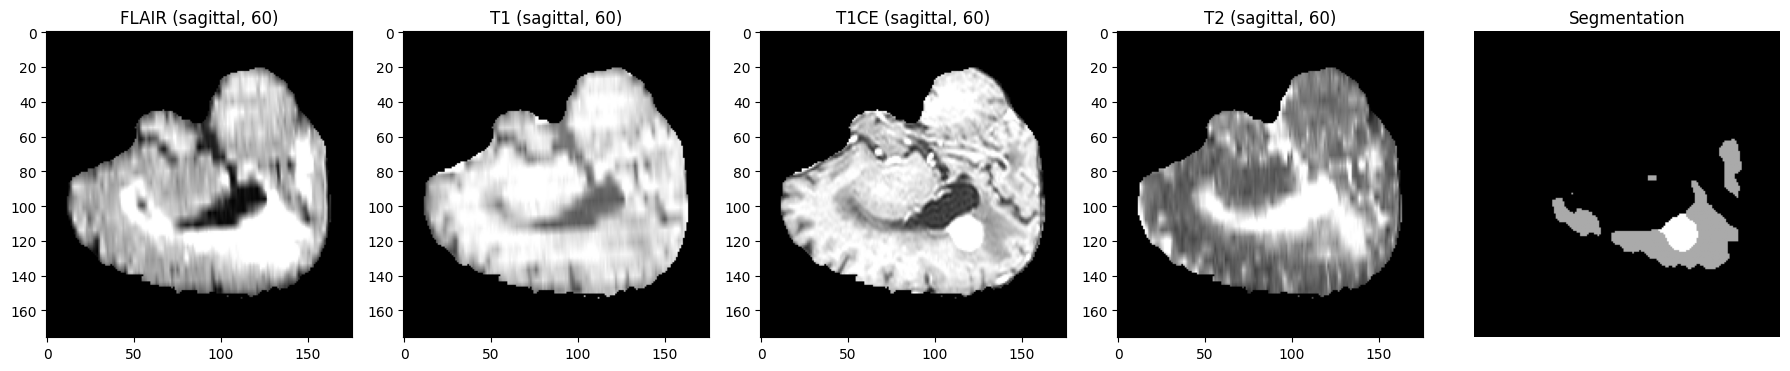

/home/leeha/Projects/brain-tumor-segmentation/transforms.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  subject_dict[key] = torch.tensor(subject_dict[key], dtype=torch.float32)
/home/leeha/Projects/brain-tumor-segmentation/transforms.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  subject_dict[key] = torch.tensor(subject_dict[key], dtype=torch.int16)


torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 155, 166, 142])
after permute torch.Size([4, 142, 166, 155])
torch.Size([176, 176, 160])


In [4]:

# dict_list = []
# dict_list.append(new_dict)
# show_sample(train_dataset, 0, "axial", train_subjects[0])
# show_sample(train_dataset, 0, "coronal", train_subjects[0])
show_sample(train_dataset, 0, "sagittal", 60)
print(train_dataset[0]["seg"].shape)

# TrainDataset.show_sample(train_dataset,  plane='axial')

In [ ]:
#Now we can train a model with our processed data

#Hyperparameters
LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_EPOCHS = 3
NUM_WORKERS = 2
PIN_MEMORY = True
LOAD_MODEL = False

def train_fn(loader, model, optimizer, loss_fn, scaler):
    loop = tqdm(loader)

    for batch_idx, batch in enumerate(loop):
        data = batch["image"].to(device=DEVICE)
        targets = batch["seg"].long().to(device=DEVICE)

        # forward
        with torch.amp.autocast("cuda"):
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        #backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        #update tqdm loop
        loop.set_postfix(loss=loss.item())

model = UNET(in_channels=4, out_channels=4).to(DEVICE) #we will need a channel for each modality
loss_fn = nn.CrossEntropyLoss() #arcsin? CHANGE THIS TO CROSS ENTROPY LOSS BECAUSE MULTI CHANNEL SEG
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)



if LOAD_MODEL:
    load_checkpoint(torch.load("my_checkpoint.pth.tar"), model)
scaler = torch.amp.GradScaler("cuda")
for epoch in range(NUM_EPOCHS):
    train_fn(train_loader, model, optimizer, loss_fn, scaler)

    #save model
    checkpoint = {
        "state_dict": model.state_dict(),
        "optimizer":optimizer.state_dict(),
    }
    save_checkpoint(checkpoint)
    #check accuracy
    check_accuracy(val_loader, model, device=DEVICE)

    #print some output to a folder
    save_predictions_as_imgs(val_loader, model, folder="saved_images/", device=DEVICE)

  0%|                                                                                           | 0/148 [00:00<?, ?it/s]

torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 140, 180, 149])
after permute torch.Size([4, 149, 180, 140])
before permute torch.Size([4, 144, 170, 148])
after permute torch.Size([4, 148, 170, 144])
before permute torch.Size([4, 143, 180, 143])
after permute torch.Size([4, 143, 180, 143])
before permute torch.Size([4, 144, 182, 147])
after permute torch.Size([4, 147, 182, 144])
torch.Size([240, 240, 155])torch.Size([240, 240, 155])

torch.Size([240, 240

  1%|▍                                                                     | 1/148 [00:49<2:00:11, 49.06s/it, loss=1.39]

torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 155, 186, 145])
after permute torch.Size([4, 145, 186, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 151, 179, 147])
after permute torch.Size([4, 147, 179, 151])


  1%|▉                                                                      | 2/148 [01:21<1:34:55, 39.01s/it, loss=1.3]

...

torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 151, 181, 142])
after permute torch.Size([4, 142, 181, 151])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 143, 185, 145])
after permute torch.Size([4, 145, 185, 143])


 10%|██████▉                                                              | 15/148 [07:23<1:07:17, 30.36s/it, loss=0.97]

torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 147, 186, 145])
after permute torch.Size([4, 145, 186, 147])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 146, 171, 144])
after permute torch.Size([4, 144, 171, 146])


 11%|███████▎                                                            | 16/148 [07:49<1:03:54, 29.05s/it, loss=0.972]

torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 148, 186, 146])
after permute torch.Size([4, 146, 186, 148])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
torch.Size([240, 240, 155])
before permute torch.Size([4, 144, 182, 149])
after permute torch.Size([4, 149, 182, 144])
